# ONS Data Joins

This notebook details join steps with ONS (Office for National Statistics) data.

By joining the FHRS data to this location-focused ONS data, area factors can be used to help predict the relative risk of a given establishment.  

Two open data files have been downloaded and saved to `../data/raw/`:

__[Lower Layer Super Output Areas](https://open-geography-portalx-ons.hub.arcgis.com/datasets/postcode-to-oa-2021-to-lsoa-to-msoa-to-lad-november-2025-best-fit-lookup-in-the-uk)__ - "A best-fit lookup between postcodes, 2021 Census Output Areas (OA), Lower Layer Super Output Areas (LSOA), Middle Layer Super Output Areas (MSOA) and local authority districts (LAD). Postcodes are as at November 2025 in the UK and are best-fitted by plotting the location of the postcode's mean address into the areas of the output geographies." **File size is approx. 416MB**

__[English indices of deprivation 2025](https://www.gov.uk/government/statistics/english-indices-of-deprivation-2025)__ - "Statistics on relative deprivation in small areas in England" **File size is approx. 2MB**

### Load, Check and prepare FSA and LSOA data for joins

First, I need to load the cleaned FSA data, followed by the LSOA postcode lookup data, checking both load steps have completed ok.  

In [1]:
# load and check cleaned FSA data:
import pandas as pd

df = pd.read_csv(
    "../data/processed/fsa_london_establishments_clean.csv",
    dtype={"PostCode": str, "postcode_tier": str} # prevent CSV mis-read on postcode fields
)

print(df.shape)
df.head()

(81217, 28)


,AddressLine1,AddressLine2,AddressLine3,AddressLine4,BusinessName,BusinessType,BusinessTypeID,ChangesByServerID,FHRSID,LocalAuthorityBusinessID,...,RatingKey,RatingValue,RightToReply,SchemeType,geocode.longitude,geocode.latitude,scores.Hygiene,scores.Structural,scores.ConfidenceInManagement,postcode_tier
0,NaN,309 Wood Lane,NaN,Dagenham,5 Elms Cafe,Restaurant/Cafe/Canteen,1,0,1714830,81398,...,fhrs_5_en-gb,5,NaN,FHRS,0.142421,51.554493,5.0,5.0,5.0,full
1,NaN,446 Becontree Avenue,NaN,Dagenham,7 TILL 11,Retailers - other,4613,0,115956,45140,...,fhrs_5_en-gb,5,NaN,FHRS,0.129392,51.558435,5.0,5.0,5.0,full
2,NaN,460 Lodge Avenue,NaN,Dagenham,Aafio Mini Market,Retailers - other,4613,0,1413686,77594,...,fhrs_5_en-gb,5,NaN,FHRS,0.110646,51.534718,5.0,5.0,0.0,full
3,NaN,North Street,NaN,Barking,Abbey Children's Centre Day Nursery,Caring Premises,5,0,128460,58427,...,fhrs_5_en-gb,5,NaN,FHRS,0.075250,51.541375,5.0,5.0,5.0,full
4,NaN,1 Hewett Road,NaN,Dagenham,Abbey Kebab & Pizza,Takeaway/sandwich shop,7844,0,122900,5136,...,fhrs_5_en-gb,5,NaN,FHRS,0.128666,51.550930,5.0,5.0,5.0,full


In [2]:
# load LSOA lookup file into memory

import pandas as pd

# only two columns are needed from this otherwise v large file
lsoa_lookup = pd.read_csv(
    "../data/raw/postcode_lsoa_lookup.csv",
    usecols=["pcds", "lsoa21cd"],
        # this approach is more efficient than loading the lot and discarding other columns
    dtype=str, # force string (lookup only data but it may look like numeric etc.)
        # and pandas likes to misinterpret code-like columns otherwise
)

# check load ok
print(lsoa_lookup.shape)
print(lsoa_lookup.head())

(2720556, 2)
      pcds   lsoa21cd
0  AB1 0AA  S01013490
1  AB1 0AB  S01013490
2  AB1 0AD  S01013490
3  AB1 0AE  S01013856
4  AB1 0AF  S01013487


-> note the `pcds` column:

Spaces are still present in the postcode column. As I will be joining on an exact string-to-string match, spacing between the two join fields needs to be consistent.  

I believe the cleanest approach will be to strip out all spaces, as they are no longer required for classifying postcode format / tiers:

In [3]:
# create new, formatted postcode column in lookup table:
lsoa_lookup["postcode_key"] = lsoa_lookup["pcds"].str.replace(" ", "", regex=False)

# create equivalent column in FSA table:
df["postcode_key"] = df["PostCode"].str.upper().str.strip().str.replace(" ", "", regex=False)

# check resulting outputs have no spaces:
print(lsoa_lookup["postcode_key"].head())
print(df["postcode_key"].head())

0    AB10AA
1    AB10AB
2    AB10AD
3    AB10AE
4    AB10AF
Name: postcode_key, dtype: str
0     RM83NH
1     RM83UB
2     RM94QS
3    IG118JA
4     RM82XT
Name: postcode_key, dtype: str


-> both outputs are of a matching 'unspaced' format and are ready to join.  

### Join FSA data - LSOA Lookup data, full postcode rows

As the FSA data has different 'tiers' of postcode completeness, different approaches are required for each when joining to the full (outward & inward code) postcodes in the lookup data.

First I will handle the full tier join:

In [4]:
# DF with full tier postcodes only
full_df = df[df["postcode_tier"] == "full"].copy()
    # .copy() ensures explicit, independent copy of filtered DF

# left join to keep all full_df rows
joined = full_df.merge( # merge used as joining on shared column
    # rather than join, for a meaningful index (e.g. an ID)
    lsoa_lookup[["postcode_key", "lsoa21cd"]], # with required columns only
    on="postcode_key",
    how="left",
)

# inspect join results
print(f"Rows going in: {len(full_df)}")
print(f"Rows coming out: {len(joined)}")

print(f"Matched (lsoa21cd field not null): {joined['lsoa21cd'].notna().sum()}")
print(f"Unmatched: {joined['lsoa21cd'].isna().sum()}")

Rows going in: 70488
Rows coming out: 70488
Matched (lsoa21cd field not null): 70422
Unmatched: 66


-> 99.9% of rows joined ok, with no duplicate matches (rows in = rows out)

An encouraging (albeit not unexpected) hit rate.  

In terms of the 66 unmatched rows:

In [5]:
# select & inspect unmatched rows:
unmatched_postcodes = joined.loc[joined["lsoa21cd"].isna(), ["PostCode", "postcode_key", "LocalAuthorityName", "RatingDate"]]
    # .loc uses two-part syntax [rows, columns], allows for simple & clean operation
    # filters rows, selects columns, prevents SettingWithCopyWarning from

print(unmatched_postcodes)

       PostCode postcode_key    LocalAuthorityName           RatingDate
505    RM10 6NH      RM106NH  Barking and Dagenham  2024-09-20T00:00:00
1523    NW2 8BB       NW28BB                Barnet  2025-10-14T00:00:00
3151    NW2 8BA       NW28BA                Barnet  1901-01-01T00:00:00
3203    NW9 7GQ       NW97GQ                Barnet  1901-01-01T00:00:00
3373    DA5 3TB       DA53TB                Bexley  2025-09-22T00:00:00
...         ...          ...                   ...                  ...
61344   E10 4QD       E104QD        Waltham Forest  2024-07-10T00:00:00
65397   W1J 7FH       W1J7FH           Westminster  2024-04-25T00:00:00
67160  SW1E 6DB      SW1E6DB           Westminster  2023-01-12T00:00:00
68445   W1K 2DA       W1K2DA           Westminster  2026-08-07T00:00:00
68557   W1K 6JV       W1K6JV           Westminster  2026-05-08T00:00:00

[66 rows x 4 columns]


-> resulting `PostCode` / `postcode_key` values _appear_ to be legitimate postcodes, despite their being unmatched with the lookup data.  

Plenty of `RatingDate` values pre-date the latest update (2025) to the lookup table, so newly-added postcodes is not an explanation here. Dates from 1901-01-01 are evidently placeholders where no visit has taken place, rather than a concern (or actual inspection date...!).    

There is a spread across boroughs, which points to actual edge cases rather than a consistent administrative issue/quirk.  

A quick search for some of the postcodes shows that many of the suffixes do not point to an existing inward code for a given outward code, which likely indicates a typo or inputting error-type issue, rather than an issue stemming from the join or the LSOA lookup data.  

As there is no dominant pattern to explain the unmatched codes, and as the unmatched rows account for less than 0.1% of the full postcode dataset, I will exclude these rows from LSOA-dependent deprivation factor analysis.  

I'll now merge the full-tier join results back into the main FSA DataFrame. This can be achieved by merging the main, unfiltered DataFrame against the lookup, rather than trying to stitch the newly-created `joined` DF back in. Full-tier rows should once again match, and partial (outward or sector tier) should not match, falling through without the need for filtering.  

While this is effectively the same join again, the steps just taken have not been wasted as they allowed for validation of the join, in isolation. 

In [6]:
# merge the entire main DF against lsoa_lookup
    # only full-tier matches should succeed
    # as outward/sector rows are too short for a full match
df = df.merge(
    lsoa_lookup[["postcode_key", "lsoa21cd"]],
    on="postcode_key",
    how="left",
)

# check shape, should be 81217 rows (unchanged) with 30 (one new) columns
print(df.shape)

# check how many LSOA lookup matches there are
# should be 70422 (same as Matched output from the join)
print(df["lsoa21cd"].notna().sum())

(81217, 30)
70423


-> shape is as expected, but one more matched row seen than expected...

In [7]:
# see matched row count by postcode_tier:
print(df.groupby("postcode_tier")["lsoa21cd"].apply(lambda x: x.notna().sum()))

postcode_tier
blank               0
full            70422
outward             0
sector              0
unclassified        1
Name: lsoa21cd, dtype: int64


-> the additional (unexpected) match is in the `unclassified` tier...

In [8]:
# find and inspect additional matched postcode:
matched_unclassified = df[(df["postcode_tier"] == "unclassified") & df["lsoa21cd"].notna()]
print(matched_unclassified[["PostCode", "postcode_key", "lsoa21cd"]])

      PostCode postcode_key   lsoa21cd
30361  E8 2 NP        E82NP  E01035641


-> `E8 2 NP`: landed in `unclassified` due to the extra spacing

Once spaces were stripped out pre-join, this becomes a legit, full-tier postcode (`E82NP` i.e. `E8 2NP`), hence the join.  

For consistency - and as it is a trivial step - I'll re-categorise this as a 'full' tier postcode:

In [9]:
# set tier to full
df.loc[(df["postcode_tier"] == "unclassified") & df["lsoa21cd"].notna(), "postcode_tier"] = "full"

# inspect count, should now show 17 unclassified
print(df["postcode_tier"].value_counts())

postcode_tier
full            70489
outward          8504
sector           1113
blank            1094
unclassified       17
Name: count, dtype: int64


-> full tier postcodes have now been merged with the LSOA lookup

I'm now moving on to the partial joins.

### Join FSA data - LSOA Lookup data, sector-only postcode rows

Sector-level partial postcodes (outward code + 1 digit of inward code, e.g. `W3 7`) provide a much more precise location than the outward code-only partial postcodes (e.g. `W3` only).  

With this in mind, I'm going to take separate approaches for joining the two to the LSOA lookup data.  

The first step for sector postcodes is to extract the sector prefix from the full postcodes in the lookup data. This _should_ be straightforward as all inward codes follow the format '1 digit + 2 letters', so slicing off the last two characters of a full postcode string should always result in a sector-level partial postcode, regardless of the outward code format.  

Matching partial codes to specific LSOAs (Lower Layer Super Output Areas) will always be a 'best guess' fallback (hence why outward code-only partials are too imprecise). My approach will be to find the most frequently seen `lsoa21cd` (LSOA ID) for each sector code, and use this as the fallback.  

I will set minimum support and purity thresholds, i.e. there have to be enough matching postcodes to make a solid guess, and a clear majority LSOA must be seen - this will ensure only a 'trustworthy' enough guess is used.  

Lastly, I'll set a 'confidence marker' which shows how an LSOA was assigned, a bit like with `postcode_tier`:

In [10]:
# get full-match postcode DF, add sector postcode column:
matched_full = df[(df["postcode_tier"] == "full") & df["lsoa21cd"].notna()].copy()
matched_full["sector_prefix"] = matched_full["postcode_key"].str[:-2] # trims the last two chars

# DF to count how many times each (sector, LSOA) combination occurs
sector_counts = (
    matched_full.groupby(["sector_prefix", "lsoa21cd"]) # group by two cols gets every unique combination
    .size() # counts frequency of each
    .reset_index(name="support_count") 
)

# Series - total matched postcodes per sector, used to calculate purity
sector_totals = sector_counts.groupby("sector_prefix")["support_count"].transform("sum")
    # .transform("sum") ensures support_count is retained along with the new sector_prefix group total
    # i.e. prevents collapsing of each group to one row (as is the case if just .sum() used)
    # this therfore inherits the same indices as the sector_counts DF

# both values are retained, with index match
    # so one can be divided by the other, to get 'purity' value
    # stored in new column in DF
sector_counts["purity"] = sector_counts["support_count"] / sector_totals

# keep only the top (most common) LSOA per sector
sector_lookup = (
    sector_counts.sort_values("support_count", ascending=False) # biggest count first
    .drop_duplicates("sector_prefix") # remove subsequent counts for sector
    .rename(columns={"lsoa21cd": "fallback_lsoa"})
)

# inspect results:
print(sector_lookup.shape)
print(sector_lookup.head())
print(sector_lookup[["support_count", "purity"]].describe())

(1101, 4)
     sector_prefix fallback_lsoa  support_count    purity
2464          KT11     E01002968            224  0.986784
7398         WC2H9     E01000918            208  0.589235
1015           E16     E01004307            160  0.416667
7394         WC2H7     E01004734            148  0.973684
6096          SW98     E01003047            147  0.622881
       support_count       purity
count    1101.000000  1101.000000
mean       27.567666     0.502229
std        23.878103     0.254692
min         1.000000     0.124138
25%        12.000000     0.305556
50%        22.000000     0.416667
75%        35.000000     0.637931
max       224.000000     1.000000


-> based on the resulting distribution:

A median purity of 41.7% is low given the intended thresholds: more than half of postcode sectors matched in London do not have a majority LSOA. Only the top quartile clears ~64% purity.  

This isn't especially surprising, as an LSOA averages around 1,500 residents - a given postcode sector will probably straddle 2, 3, or 4 LSOAs. 

This is also why a support count threshold is important - a sector with 1 matched postcode will have 100% purity, but is not a solid enough fallback to work with.  

In [11]:
MIN_SUPPORT = 5
MIN_PURITY = 0.6

reliable_lookup = sector_lookup[
    (sector_lookup["support_count"] >= MIN_SUPPORT) & # ensure enough matches
    (sector_lookup["purity"] >= MIN_PURITY) # ensure sufficient majorityq
][
    ["sector_prefix", "fallback_lsoa"] # columns needed
]

# inspect sectors which pass as 'fallback' candidates
print(f"{len(reliable_lookup)} of {len(sector_lookup)} sectors pass both thresholds")

# only target rows that are explicitly sector-tier and still unmatched
sector_only = (df["postcode_tier"] == "sector") & df["lsoa21cd"].isna()
    # prevents outward-tier postcodes (N16) slipping through as sectors (N1 6)!

# convert DF, currently [(index), sector_prefix, fallback_lsoa] to lookup table
    # sector_prefix becomes the index, fallback_lsoa becomes Series
fallback_map = reliable_lookup.set_index("sector_prefix")["fallback_lsoa"]
    # in effect, now a dictionary


# write 'passing' fallback LSOA refs into matching sector rows:
# -- an explainer as I know I'll need this in future if I come back to this bit...
# 1. pull out postcode_key values where sector_only (row filter) is true (RH side)
# 2. map() looks up each resulting series as a key against fallback_map
    # swaps for a matching value, or NaN if a sector postcode isn't in the fallback (unmatched)
    # the result is a new Series, but it inherits the same row index
# 3. writes values into `lsoa21cd` column but only for the same set of rows (LH side)
df.loc[sector_only, "lsoa21cd"] = df.loc[sector_only, "postcode_key"].map(fallback_map)
    # simpler alternative approaches (e.g. merge) are easier to read but less safe - going with this one

# see if it's all been worth it:
print(f"Sector-tier rows now matched: {sector_only.sum() - df.loc[sector_only, 'lsoa21cd'].isna().sum()} of {sector_only.sum()}")

264 of 1101 sectors pass both thresholds
Sector-tier rows now matched: 39 of 1113


-> 39 of 1113 sector postcodes gained a fallback LSOA ref

Not a great hit rate for the work done, but preferable to bad guesswork...!   

In order to check whether this low hit rate is due to the strictness of thresholds, or sectors not having any candidate in the matched full-postcode data:

In [12]:
unmatched_prefixes = df.loc[sector_only, "postcode_key"]
all_lookup_prefixes = set(sector_lookup["sector_prefix"])
reliable_prefixes = set(reliable_lookup["sector_prefix"])

print(f"Unique sector prefixes among unmatched rows: {unmatched_prefixes.nunique()}")
print(f"Total sector-level postcodes which also appear anywhere in matched data: {unmatched_prefixes.isin(all_lookup_prefixes).sum()}")
print(f"...of which passed both thresholds: {unmatched_prefixes.isin(reliable_prefixes).sum()}")

Unique sector prefixes among unmatched rows: 113
Total sector-level postcodes which also appear anywhere in matched data: 1113
...of which passed both thresholds: 39


-> all 113 unique sectors in the unmatched, sector-tier rows have some supporting data

As all 1113 sector postcode rows appear in the already matched data.

This does at least confirm that the thresholds did their job, and I can be confident enough in the rows that did match.  

Lastly, I'll add the LSOA 'confidence marker' column to avoid guesses being treated as actual matches:

In [13]:
# add match type (confidence) column for LSOA refs:
import numpy as np

df["lsoa_match_type"] = np.select(
    condlist=[
        (df["postcode_tier"] == "full") & df["lsoa21cd"].notna(),
        (df["postcode_tier"] == "sector") & df["lsoa21cd"].notna(),
    ],
    choicelist=["full_match", "sector_fallback"],
    default="unmatched",
)

print(df["lsoa_match_type"].value_counts())

lsoa_match_type
full_match         70423
unmatched          10755
sector_fallback       39
Name: count, dtype: int64


-> resulting counts align with expected values.

In terms of where this now leaves us:

In [14]:
# check LSOA ref matches in main DF
total_matched = df["lsoa21cd"].notna().sum()
print(f"Total with LSOA: {total_matched} of {len(df)} ({total_matched/len(df):.1%})")

Total with LSOA: 70462 of 81217 (86.8%)


-> based on the full postcode join, and fallback LSOA refs for sector codes:

All full postcode rows now have a LSOA reference, as well as 39 sector-tier rows which have 'best guess' LSOA refs applied based on the full-code matches.  

Remaining unmatched rows remain so by design:
- sector-tier rows without a strong enough fallback candidate
- outward-tier rows as the location provided is too imprecise
- blank or unclassified-tier rows as no useable information is available

It is theoretically possible to backfill full postcodes from `geocode` data, however, earlier investigation in the cleaning stage identified that 100% of sector-tier rows were also missing geocode (lat/longitude) data. This reflects the earlier conclusion that establishments with partial/missing location data are often mobile or non-fixed businesses: it may be the case that they simply can't - and shouldn't - be mapped against a given LSOA.  

As seen in the cleaning step: 575 of the 1094 blank postcode rows have geocode data, and are therefore theoretically recoverable, however this would involve a new piece of infrastructure (with resultant complexity) adding to facilitate this. Given this accounts for under 1% of the overall dataset, I'm parking it for now but will add it as a possible 'future enhancement'.  

The current 86.8% match rate (resulting in 70.5k LSOA-ref matched rows) is sufficient to proceed to the IMD 2025 deprivation data join step.  



### Join LSOA-ref matched FSA data to IMD data

I'll now join the FSA establishment data to the IMD data, now that LSOA references have been added (where applicable). Rows without LSOA refs cannot be joined to the IMD data.  

The IMD data shows deprivation levels by LSOA (Lower Layer Super Output Area), each covering an area with a population of around 1,500 people - a relatively high level of granularity.  

`lsoa_match_type` (added in the previous section) will carry through this join, so IMD-derived deprivation figures can still be distinguished as coming from a precise postcode match versus a sector-level best guess.

The intention here is to see if any socio-economic factors provide an indication of likely FHRS rating.  

First, I'll load and inspect the IMD file:

In [15]:
# load IMD data into memory, inspect
imd = pd.read_csv("../data/raw/imd_2025_lsoa.csv")

print(imd.shape)
print(imd.columns.tolist())
imd.head()

(33755, 6)
['LSOA code (2021)', 'LSOA name (2021)', 'Local Authority District code (2024)', 'Local Authority District name (2024)', 'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)', 'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA']


,LSOA code (2021),LSOA name (2021),Local Authority District code (2024),Local Authority District name (2024),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA
0,E01000001,City of London 001A,E09000001,City of London,26525,8
1,E01000002,City of London 001B,E09000001,City of London,31203,10
2,E01000003,City of London 001C,E09000001,City of London,25913,8
3,E01000005,City of London 001E,E09000001,City of London,14807,5
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,10917,4


-> column names are unwieldy with possible truncation (perhaps from .xlsx -> CSV step)

As such, I'll rename the columns to more usable names before completing the join:

In [16]:
# rename IMD data columns and check
imd.columns = ["lsoa21cd", "lsoa21nm", "lad_code", "lad_name", "imd_rank", "imd_decile"]

print(imd.columns.tolist())
imd.head()

['lsoa21cd', 'lsoa21nm', 'lad_code', 'lad_name', 'imd_rank', 'imd_decile']


,lsoa21cd,lsoa21nm,lad_code,lad_name,imd_rank,imd_decile
0,E01000001,City of London 001A,E09000001,City of London,26525,8
1,E01000002,City of London 001B,E09000001,City of London,31203,10
2,E01000003,City of London 001C,E09000001,City of London,25913,8
3,E01000005,City of London 001E,E09000001,City of London,14807,5
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,10917,4


In [17]:
# join main DF to IMD data on LSOA id field
df = df.merge(
    imd[["lsoa21cd", "imd_rank", "imd_decile"]],
    on="lsoa21cd",
    how="left", # unmatched rows remain
)

print(df.shape)
print(df["imd_rank"].notna().sum())

(81217, 33)
70462


-> exact matches (70,462 joined rows, same as the 'Total with LSOA check')

I can then move on to the core question: does deprivation correlate with rating?

In [18]:
# pull out rows with gradable FHRS rating, and IMD data match:
gradable = df[df["RatingValue"].isin(["0","1","2","3","4","5"]) & df["imd_decile"].notna()].copy()

# coerce numeric-only gradable ratings to integer
gradable["rating_int"] = gradable["RatingValue"].astype(int)

# convert continuous rating integer numbers into bands
gradable["tier"] = pd.cut(
    gradable["rating_int"],
    bins=[-1, 2, 4, 5], # defines edges, i.e. above -1 up to 2 and so on
    labels=["critical", "fail", "pass"], # assign label to each bin
)

print(len(gradable)) # total rows with gradable rating and IMD data

# get and show IMD decile by each tier (n.b. - lower = more deprived area)
decile_by_tier = gradable.groupby("tier")["imd_decile"].mean()
print(decile_by_tier)

63409
tier
critical    3.823194
fail        4.306419
pass        4.928752
Name: imd_decile, dtype: float64


-> initial results indicate a trend across the three bands

This supports the initial hypothesis that establishments with 'critical' ratings sit, on average, in noticeably more deprived areas. 

That said, means alone don't paint the full picture: how much do these three groups overlap, and is the gap statistically significant (rather than noise).  

Next, I'll check group sizes and spread:

In [19]:
# inspect group size and spread alongside mean, by rating tier
tier_summary = gradable.groupby("tier")["imd_decile"].agg(["count", "mean", "std"])
print(tier_summary)

          count      mean       std
tier                               
critical   3863  3.823194  2.029829
fail      17215  4.306419  2.208708
pass      42331  4.928752  2.348369


-> sizeable groups are still seen across all three tiers, so nothing seen so far rests on just a few establishments.

However, the `std` column indicates substantial overlap between the three groups, as spread is roughly 2.0-2.35 across all tiers - some further examination is required.  

### IMD join - formal significance testing

In order to investigate further, I am going to use the [Kruskal-Wallis Test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html), selected (with _Claude's_ guidance, as I am nearing the fringes of my current understanding) as `imd_decile` is an ordinal, and the underlying data is not necessarily normally distributed. 

My understanding here is that the _one-way ANOVA_ (analysis of variance) test is the typical choice for examining 'numeric-ish' variables across more than two independent groups. This was ruled out as an approach as some of its key assumptions are broken here:

- **Interval-scale data**, i.e. the outcome is a continuous measurement where equal numeric gaps mean equal real-world gaps, so the distance between 3 and 4 should mean the same as the distance between 8 and 9. In this case, `imd_decile` isn't a measurement, but a **rank bucket** - as such, the gaps between deciles do not necessarily translate to the corresponding deprivation differences. Thus, we cannot assume a clean interval scale here.  

- **Normality within each group**, i.e. the assumption that each group's values are roughly normally distributed. The decile will be roughly uniform across the whole national population, but once the data has been filtered down to 'establishments with a critical FHRS score in London' we can no longer assume uniform distribution.  

- **Equal variances across groups**, i.e. homogeneity of variance: this assumption is broken by the finding that standard deviations of `2.03`, `2.21` and `2.35` are seen across the three tiers. While not wildly different, they are not equal either, and the unbalanced group sizes will further degrade ANOVA's reliability.  

Each of these in isolation may not be prohibitive, however in combination they are enough to make an alternative approach a potential better choice. 

This is where the _Kruskal-Wallis_ test comes in, as the non-parametric (i.e. no assumption that the data follows a specific distribution) equivalent to ANOVA. It works by converting every value to its rank across the combined dataset and then comparing ranks (rather than raw values) across the groups. Thus, there is no reliance on the above assumptions, and a suitable alternative test has been found. 

I'll output three measures:
- H-value: measures how far apart the average global ranks of each group are from what we'd expect, if tier membership had no relationship to the deprivation decile.  
- p-value: measures the probability of (a result at least as extreme as) the observed results occuring by random chance.  
- epsilon-squared (effect size): measures the proportion of the variation in `imd_decile` which can be explained by tier membership. The formula for this is `(H − k + 1) / (n − k)`, using the Kruskal-Wallis H-value `H`, group count `k` and observations `n`.    

In [20]:
from scipy import stats

# separate each group into a series, saved to a single variable to pass to test
groups = [gradable.loc[gradable["tier"] == t, "imd_decile"] for t in ["critical", "fail", "pass"]]
    # equivalent to (critical_series, fail_series, pass_series) to be passed as *args below

# stats.kruskal() expects each group to be passed as a separate arg, see above
h_stat, p_value = stats.kruskal(*groups)
print(f"H statistic: {h_stat:.2f}")
print(f"p-value: {p_value:.2e}") # scientific notation used as p-value likely to be very small

# measure effect size 
n = len(gradable)
k = 3
epsilon_squared = (h_stat - k + 1) / (n - k)
    # this is the appropriate effect size measurement for K-W test
print(f"Effect size (epsilon-squared): {epsilon_squared:.4f}")

H statistic: 1477.18
p-value: 0.00e+00
Effect size (epsilon-squared): 0.0233


-> based on the three measures output:

An H-value of 1477.18 indicates a non-random pattern, although it does not detail how much the pattern matters practically.  
A p-value of (effectively) zero similarly indicates a real and non-random relationship.  
An effect size of around 2.3% is small (rough bands being ~0.01 small, ~0.06 medium, ~0.14 large).  

What this tells me is that there is a statistically significant but modest relationship between IMD decile and FHRS Rating bandings.  

This is a useful signal, but not a standalone predictor: likely to be useful in combination with other features.  

### Visualising the FHRS Rating band - IMD decile relationship:

In order to gain visual confirmation of what I've seen so far, I'll plot the relationship between the Rating groups and IMD decile:

Matplotlib is building the font cache; this may take a moment.


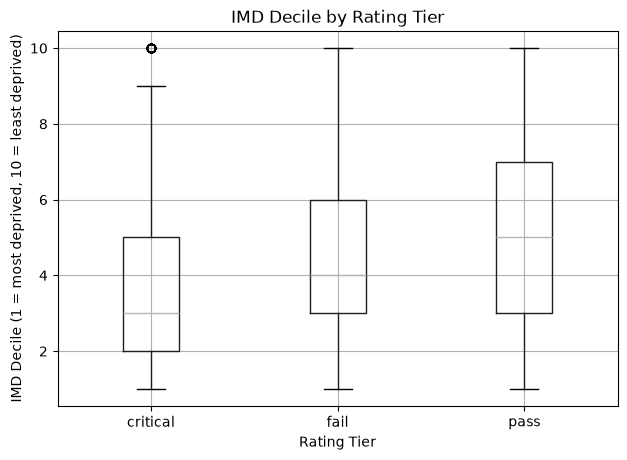

In [ ]:
import matplotlib.pyplot as plt

gradable.boxplot(column="imd_decile", by="tier", figsize=(7, 5))
plt.title("IMD Decile by Rating Tier")
plt.suptitle("")  # removes the default, redundant auto-title pandas adds
plt.xlabel("FHRS Rating Tier")
plt.ylabel("IMD Decile (1 = most deprived, 10 = least deprived)")
plt.show()

-> the plot provides the expected visual confirmation to match the Kruskal-Wallis results.

- Medians step upward as expected (critical ~ 3, fail ~ 4, pass ~ 5)
- The boxes overlap substantially

Again, what is shown is a real but modest finding, with significant overlap between groups.  

Notably, at least one critical-rated establishment sits in London's least deprived decile (10), flagged as a statistical outlier on the critical group's boxplot (the circle above the whisker). This serves as a reminder the relationship is a population-level trend, not an individual-level rule.   